In [1]:
#@title Imports

import random
import os
import sys
import zipfile
import ee

from dataclasses import dataclass
from pathlib import Path
from google.colab import auth, drive

In [2]:
#@title Google auth + Mount Drive + Optional clone

root_path = "/content/drive/MyDrive/MSc/STURM-fusion"  #@param {type:"string", multiline:true}
mount_point = "/content/drive"  #@param {type:"string"}
clone_repo = False  #@param {type:"boolean"}

# Always authenticate + mount
drive.mount(mount_point)

repo_url = "https://github.com/TAX2310/STURM-fusion.git"

if clone_repo:
    project_root = os.path.join(root_path, "STURM-fusion")
    if not os.path.exists(project_root):
        !git clone {repo_url} "{project_root}"
else:
    project_root = root_path

sys.path.append(project_root)

from config.config import CFG
cfg = CFG()
cfg.ROOT = Path(project_root)
cfg.DRIVE_ROOT = Path(mount_point) / "MyDrive"

print("✅ ROOT:", cfg.ROOT)
print("✅ DRIVE_ROOT:", cfg.DRIVE_ROOT)

Mounted at /content/drive
✅ ROOT: /content/drive/MyDrive/MSc/STURM-fusion
✅ DRIVE_ROOT: /content/drive/MyDrive


In [3]:
from src.data.sturm_flood import *
from src.pipeline.build_dataset import *
from src.utils.io import *
from src.gee.tasks import has_active_tasks
from src.huggingface.push_dataset import push_zip_to_hf

In [4]:
download_and_extract(cfg)

✅ Zip already exists or dataset present, skipping download.
✅ Dataset already extracted, skipping unzip.


In [5]:
import pandas as pd

csv_path = cfg.NEW_METADATA_PATH / 'metadata.csv'

df = pd.read_csv(csv_path)

In [6]:
#df = df[df["ems_code"] != "EMSR488"]
#df = df[df["ems_code"] != "EMSR501"]

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio


def append_mask_pixel_counts(
    df: pd.DataFrame,
    mask_dir: str | Path,
    tile_col: str = "tile_id",
    class_values: list[int] | None = None,
) -> pd.DataFrame:
    """
    For each tile_id in df, load the corresponding flood mask and count pixel values.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a tile ID column.
    mask_dir : str | Path
        Folder containing the flood mask .tif files.
    tile_col : str
        Name of the column in df containing the tile ID / filename stem.
    mask_suffix : str
        Optional suffix added after tile_id before the file extension.
        Example: tile_id='abc', mask_suffix='_mask' -> abc_mask.tif
    extension : str
        Mask file extension, default '.tif'.
    class_values : list[int] | None
        Specific class values to count. If None, uses STURM classes:
        [0, 1, 2, 3, 4, 5, 99]

    Returns
    -------
    pd.DataFrame
        Copy of df with added count columns.
    """
    mask_dir = Path(mask_dir)
    out_df = df.copy()

    if class_values is None:
        class_values = [0, 1, 2, 3, 4, 5, 99]

    count_rows = []

    for tile_id in out_df[tile_col]:
        print(tile_id)
        mask_path = mask_dir / f"{tile_id}"

        # Default row of NaNs in case file is missing
        row_counts = {f"count_{v}": np.nan for v in class_values}
        row_counts["mask_found"] = False
        row_counts["total_pixels"] = np.nan

        if mask_path.exists():
            with rasterio.open(mask_path) as src:
                mask = src.read(1)  # first band

            values, counts = np.unique(mask, return_counts=True)
            value_count_map = dict(zip(values.tolist(), counts.tolist()))

            for v in class_values:
                row_counts[f"count_{v}"] = value_count_map.get(v, 0)

            row_counts["mask_found"] = True
            row_counts["total_pixels"] = mask.size

        count_rows.append(row_counts)

    counts_df = pd.DataFrame(count_rows, index=out_df.index)
    out_df = pd.concat([out_df, counts_df], axis=1)

    return out_df

In [8]:
#df_with_counts = append_mask_pixel_counts(df,mask_dir=cfg.NEW_MASK_PATH,tile_col="tile_id")

In [9]:
#save_dataframe_to_csv(df_with_counts, '/content/tmp_data.csv')

In [10]:
#csv_path = cfg.ROOT / 'tmp_data.csv'

#df = pd.read_csv(csv_path)

In [11]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def convert_multi_class_mask_png(
    input_path,
    output_dir,
    colors,
    nodata=99
):
    """
    Save a multi-class flood mask as a coloured PNG.
    Output keeps same filename, changes extension to .png
    """

    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Create output path with same name but .png
    output_path = output_dir / (input_path.stem + ".png")

    # Load mask
    with rasterio.open(input_path) as src:
        mask = src.read(1)

    # Handle NoData
    mask = mask.astype(np.float32)
    mask[mask == nodata] = np.nan

    # Create colormap
    cmap = ListedColormap(colors)

    # Define class boundaries (0,1,2,...)
    bounds = np.arange(len(colors) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    # Plot + save
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap=cmap, norm=norm)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

    return output_path

In [12]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


def convert_binary_class_mask_png(
    input_path,
    output_dir,
    colors,
    nodata=99
):
    """
    Save a binary flood mask as a coloured PNG.
    Output keeps same filename, changes extension to .png
    """

    if len(colors) != 2:
        raise ValueError("Binary mask requires exactly 2 colours")

    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Create output path with same name but .png
    output_path = output_dir / (input_path.stem + ".png")

    # Load mask
    with rasterio.open(input_path) as src:
        mask = src.read(1)

    # Handle NoData
    mask = mask.astype(np.float32)
    mask[mask == nodata] = np.nan

    # Colormap
    cmap = ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5]
    norm = BoundaryNorm(bounds, cmap.N)

    # Plot + save
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap=cmap, norm=norm)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close()

    return output_path

In [13]:
def convert_s1_grayscale_bands_png(
    input_path,
    output_dir,
    band_names=None
):
    """
    Save both Sentinel-1 bands as grayscale PNGs.

    Parameters
    ----------
    input_path : str | Path
        Path to input S1 .tif
    output_dir : str | Path
        Output directory
    band_names : list | None
        Optional band name suffixes, e.g. ["VV", "VH"].
        If None, uses ["band1", "band2"].

    Returns
    -------
    list[Path]
        Output file paths
    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if band_names is None:
        band_names = ["VV", "VH"]

    if len(band_names) != 2:
        raise ValueError("band_names must have length 2")

    output_paths = []

    with rasterio.open(input_path) as src:
        for i in range(2):
            img = src.read(i + 1).astype(np.float32)
            img = _percentile_stretch(img)

            output_path = output_dir / f"{input_path.stem}_{band_names[i]}.png"

            plt.figure(figsize=(6, 6))
            plt.imshow(img, cmap="gray")
            plt.axis("off")
            plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
            plt.close()

            output_paths.append(output_path)

    return output_paths

In [15]:
from pathlib import Path
import numpy as np
import rasterio
import matplotlib.pyplot as plt


def _percentile_stretch(arr, lower=2, upper=98):
    arr = arr.astype(np.float32)

    valid = np.isfinite(arr)
    if not np.any(valid):
        return np.zeros_like(arr, dtype=np.float32)

    lo = np.percentile(arr[valid], lower)
    hi = np.percentile(arr[valid], upper)

    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)

    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo)
    return arr

In [16]:
from pathlib import Path
import numpy as np
import rasterio
from pathlib import Path
import numpy as np
import rasterio

def convert_mask_to_binary(
    input_path: str | Path,
    output_dir: str | Path,
    overwrite: bool = False
) -> Path:
    """
    Convert a STURM flood mask to binary and save it.

    1 = flood (any value > 0 except 99)
    0 = non-flood
    99 = NoData (preserved)

    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / input_path.name

    if output_path.exists() and not overwrite:
        return output_path

    # Load mask
    with rasterio.open(input_path) as src:
        mask = src.read(1)
        profile = src.profile

    # Convert to binary
    binary = np.zeros_like(mask, dtype=np.uint8)

    binary[(mask > 0) & (mask != 99)] = 1   # flood
    binary[mask == 99] = 99                 # preserve NoData

    # Update profile
    profile.update(
        dtype=rasterio.uint8,
        count=1,
        compress="lzw",
        nodata=99
    )

    # Save
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(binary, 1)

    return output_path

In [17]:
from pathlib import Path
import shutil


def copy_file(src_path: str | Path, dst_path: str | Path, overwrite: bool = False) -> Path:
    src_path = Path(src_path)
    dst_path = Path(dst_path)

    if not src_path.exists():
        raise FileNotFoundError(f"Source file not found: {src_path}")

    if dst_path.exists() and not overwrite:
        return dst_path

    dst_path.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(src_path, dst_path)  # preserves metadata

    return dst_path

In [19]:
def get_all_images(file, folder_name):
  m_c_colors = [
    "black",    # 0 background
    "blue",     # 1 flood
    "green",    # 2 river
    "cyan",     # 3 water
    "orange",   # 4 reservoir
    "purple"    # 5 lake
  ]

  b_colors = [
    "black",    # 0 background
    "blue",     # 1 flood
  ]

  copy_file(
    src_path=cfg.NEW_S1_PATH / file,
    dst_path= folder_name / ("S1/" + file),
  )

  copy_file(
    src_path=cfg.NEW_S2_PATH / file,
    dst_path= folder_name / ("S2/" + file),
  )

  copy_file(
    src_path=cfg.NEW_MASK_PATH / file,
    dst_path= folder_name / ("f_m_m/" + file),
  )

  convert_mask_to_binary(
      input_path=cfg.NEW_MASK_PATH / file ,
      output_dir= folder_name / "f_m_b",
  )

  convert_multi_class_mask_png(
    cfg.NEW_MASK_PATH / file,
    folder_name / "f_m_m/",
    m_c_colors
  )

  convert_binary_class_mask_png(
    folder_name / ("f_m_b/" + file),
    folder_name / "f_m_b/",
    b_colors
  )

  convert_s1_grayscale_bands_png(
    cfg.NEW_S1_PATH / file,
    folder_name / "S1",
    band_names=["VV", "VH"]
  )

  convert_s1_pseudo_rgb_png(
      cfg.NEW_S1_PATH / file,
      folder_name / "S1"
  )

In [20]:
def create_image_export(images, folder_name):
  os.makedirs(folder_name, exist_ok=True)
  os.makedirs(folder_name / "S1", exist_ok=True)
  os.makedirs(folder_name / "S2", exist_ok=True)
  os.makedirs(folder_name / "f_m_m", exist_ok=True)
  os.makedirs(folder_name / "f_m_b", exist_ok=True)

  for image in images:
    get_all_images(image, folder_name)

  shutil.make_archive(folder_name, 'zip', folder_name)
  return folder_name

In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import string


def create_image_grid(image_paths, captions=None, ncols=3, figsize=(12, 8), output_path=None):
    """
    Create a grid of images with captions underneath.

    Parameters
    ----------
    image_paths : list
        List of image file paths
    captions : list
        List of captions (same length as image_paths)
    ncols : int
        Number of columns
    figsize : tuple
        Figure size
    output_path : str | None
        If provided, saves the figure
    """

    if captions is None:
        letters = list(string.ascii_lowercase)

        captions = []
        for i in range(len(image_paths)):
            letter = letters[i % 26]
            repeat = (i // 26) + 1
            captions.append(f"({letter * repeat}) {image_paths[i].stem}")

    n_images = len(image_paths)
    nrows = (n_images + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()

    for i, (img_path, caption) in enumerate(zip(image_paths, captions)):
        img = Image.open(img_path)

        axes[i].imshow(img)
        axes[i].axis("off")

        # Caption UNDER the image
        axes[i].set_title(caption, fontsize=10, y=-0.15)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

In [22]:
def create_path_lists(images, folder_name):
  b_images = [folder_name / "f_m_b" / i for i  in images]
  m_images = [folder_name / "f_m_m" / i for i  in images]
  s1_images = [folder_name / "S1" / i for i  in images]
  s2_images = [folder_name / "S2" / i for i  in images]

  return b_images, m_images, s1_images, s2_images

#Create Figures

In [23]:
images = ['EMSR292_01CHRISOUPOLI_10_03_1_1', 'EMSR470_AOI01_33_10_1_2', 'EMSR407_AOI01_04_14_2_1', 'EMSR470_AOI01_44_09_2_1']

In [24]:
# Multi class distrobution
images_tif = [i + ".tif" for i  in images]
print(images_tif)

folder_name = "/content/binary_v_multi"
folder_name = Path(folder_name)

zip_file = create_image_export(images_tif, folder_name)


['EMSR292_01CHRISOUPOLI_10_03_1_1.tif', 'EMSR470_AOI01_33_10_1_2.tif', 'EMSR407_AOI01_04_14_2_1.tif', 'EMSR470_AOI01_44_09_2_1.tif']


In [25]:
import shutil

#files.download('/content/temp_data.zip')

['EMSR292_01CHRISOUPOLI_10_03_1_1.png', 'EMSR470_AOI01_33_10_1_2.png', 'EMSR407_AOI01_04_14_2_1.png', 'EMSR470_AOI01_44_09_2_1.png']


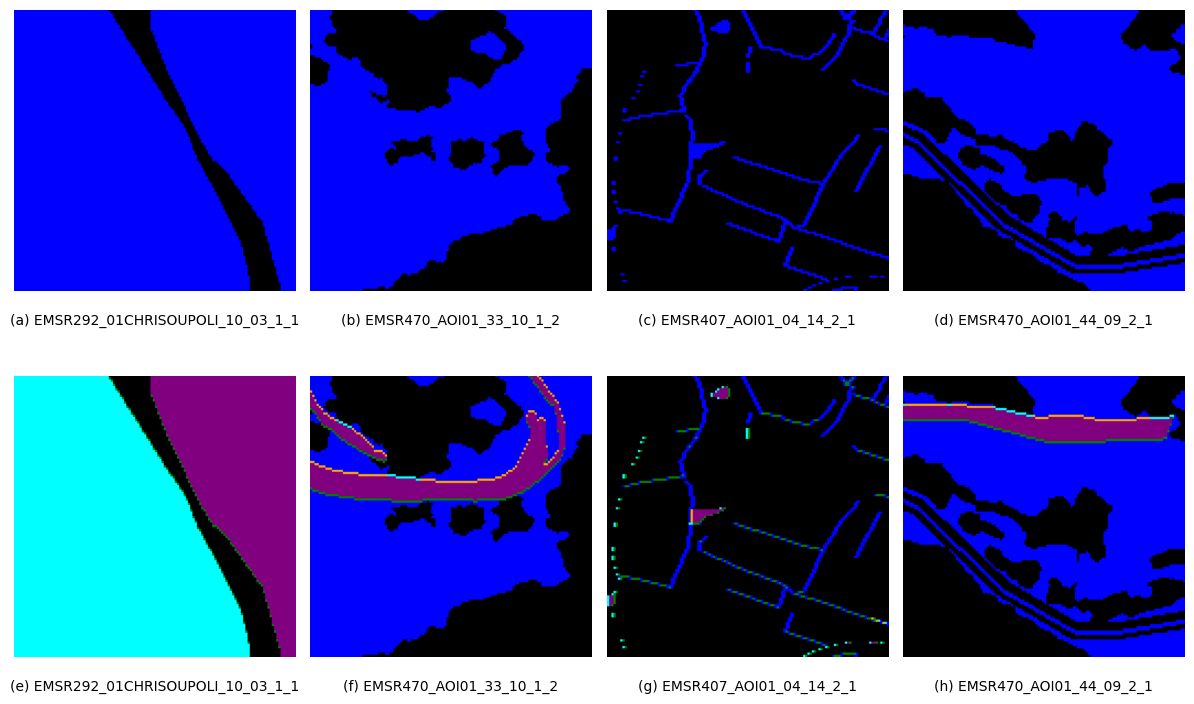

In [26]:
images_png = [i + ".png" for i  in images]
print(images_png)

b_images, m_images, s1_images, s2_images = create_path_lists(images_png, folder_name)

create_image_grid(
    b_images + m_images,
    ncols=4,
    output_path="image_grid.png"
)

In [36]:
def convert_s1_pseudo_rgb_png(
    input_path,
    output_dir
):
    """
    Save Sentinel-1 as a pseudo-RGB PNG.

    RGB mapping:
    R = band 1
    G = band 2
    B = band 1 - band 2

    Parameters
    ----------
    input_path : str | Path
        Path to input S1 .tif
    output_dir : str | Path
        Output directory

    Returns
    -------
    Path
        Output file path
    """
    input_path = Path(input_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    output_path = output_dir / f"{input_path.stem}.png"

    with rasterio.open(input_path) as src:
        print("count:", src.count)
        print("dtypes:", src.dtypes)
        print("nodata:", src.nodata)

        band1 = src.read(1)
        band2 = src.read(2)
        print(band1)
        print(band2)

        print("band1 unique sample:", np.unique(band1[~np.isnan(band1)])[:20] if np.issubdtype(band1.dtype, np.floating) else np.unique(band1)[:20])
        print("band2 unique sample:", np.unique(band2[~np.isnan(band2)])[:20] if np.issubdtype(band2.dtype, np.floating) else np.unique(band2)[:20])

        print("band1 all nan:", np.isnan(band1).all() if np.issubdtype(band1.dtype, np.floating) else False)
        print("band2 all nan:", np.isnan(band2).all() if np.issubdtype(band2.dtype, np.floating) else False)

    r = _percentile_stretch(band1)
    g = _percentile_stretch(band2)
    b = _percentile_stretch(band1 - band2)

    rgb = np.dstack([r, g, b])

    plt.figure(figsize=(6, 6))
    plt.imshow(rgb)
    plt.axis("off")
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

    return output_path

count: 2
dtypes: ('float32', 'float32')
nodata: None
[[-16.342268  -14.7898    -13.45038   ... -20.84396   -21.484472
  -21.714268 ]
 [-15.85171   -15.455068  -13.531136  ... -20.721977  -22.137478
  -22.29619  ]
 [-16.407955  -16.825436  -13.782291  ... -21.021408  -22.263643
  -22.276615 ]
 ...
 [-21.783558  -21.553885  -22.0286    ...  -8.970792   -8.044134
   -7.7356977]
 [-21.576275  -21.932629  -22.301094  ...  -9.647534   -8.151501
   -7.5083423]
 [-21.295872  -22.519995  -23.940609  ...  -9.833285   -8.233643
   -7.4113045]]
[[-18.424421 -19.184593 -19.592306 ... -26.893911 -27.316078 -27.07161 ]
 [-17.65167  -18.806221 -19.809515 ... -27.515356 -27.018112 -27.035984]
 [-17.020227 -19.41085  -21.385155 ... -29.60258  -27.391672 -27.436756]
 ...
 [-27.96459  -27.561579 -27.598082 ... -14.012336 -13.601032 -13.15051 ]
 [-28.320614 -26.88019  -26.064842 ... -13.938321 -13.472475 -12.929966]
 [-27.759193 -26.92741  -26.012577 ... -13.673667 -13.487094 -12.966846]]
band1 unique samp

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


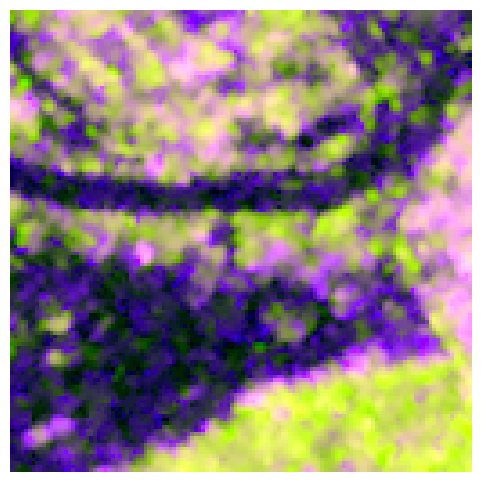

PosixPath('EMSR470_AOI01_33_10_1_2.png')

In [38]:
convert_s1_pseudo_rgb_png(
    cfg.NEW_S1_PATH / "EMSR470_AOI01_33_10_1_2.tif",
    "./"
)

In [39]:
from pathlib import Path
import numpy as np
import rasterio


def count_nan_files(input_dir, return_files=False):
    """
    Count how many raster files contain NaN values.

    Parameters
    ----------
    input_dir : str | Path
        Directory containing .tif files
    return_files : bool
        If True, also return list of files with NaNs

    Returns
    -------
    int or (int, list)
        Number of files with NaNs
        optionally list of file paths
    """

    input_dir = Path(input_dir)

    nan_count = 0
    nan_files = []

    for file_path in input_dir.glob("*.tif"):
        with rasterio.open(file_path) as src:
            has_nan = False

            for b in range(1, src.count + 1):
                band = src.read(b)

                if np.issubdtype(band.dtype, np.floating):
                    if np.isnan(band).any():
                        has_nan = True
                        break

            if has_nan:
                nan_count += 1
                nan_files.append(file_path)

    if return_files:
        return nan_count, nan_files

    return nan_count

In [41]:
def count_all_nan_files(input_dir):
    from pathlib import Path
    import numpy as np
    import rasterio

    input_dir = Path(input_dir)
    all_nan_files = []

    for file_path in input_dir.glob("*.tif"):
        with rasterio.open(file_path) as src:
            file_all_nan = True

            for b in range(1, src.count + 1):
                band = src.read(b)
                if np.issubdtype(band.dtype, np.floating):
                    if not np.isnan(band).all():
                        file_all_nan = False
                        break
                else:
                    file_all_nan = False
                    break

            if file_all_nan:
                all_nan_files.append(file_path)

    return len(all_nan_files), all_nan_files

In [40]:
nan_count, nan_files = count_nan_files(cfg.NEW_S1_PATH, return_files=True)
print(f"Number of files with NaNs: {nan_count}")

Number of files with NaNs: 398


In [44]:
nan_count, nan_files = count_all_nan_files(cfg.NEW_S1_PATH)
print(f"Number of files with all NaNs: {nan_count}")

Number of files with all NaNs: 398


In [47]:
for file in nan_files:
  print(file.stem)

EMSR479_AOI02_34_21_2_1
EMSR501_AOI01_08_01_1_2
EMSR554_AOI03_02_03_1_2
EMSR554_AOI03_02_03_2_2
EMSR554_AOI03_02_04_1_1
EMSR554_AOI03_02_04_2_1
EMSR554_AOI03_02_04_1_2
EMSR554_AOI03_02_04_2_2
EMSR554_AOI03_02_05_1_1
EMSR554_AOI03_02_05_1_2
EMSR554_AOI03_02_05_2_2
EMSR554_AOI03_02_06_2_1
EMSR554_AOI03_02_06_2_2
EMSR554_AOI03_02_07_1_1
EMSR554_AOI03_02_07_1_2
EMSR554_AOI03_02_08_1_1
EMSR554_AOI03_02_08_2_1
EMSR554_AOI03_02_08_1_2
EMSR554_AOI03_02_09_1_1
EMSR554_AOI03_02_09_1_2
EMSR554_AOI03_02_08_2_2
EMSR554_AOI03_02_11_1_2
EMSR554_AOI03_02_09_2_1
EMSR554_AOI03_02_09_2_2
EMSR554_AOI03_02_11_1_1
EMSR554_AOI03_02_10_2_1
EMSR554_AOI03_02_11_2_2
EMSR554_AOI03_02_12_2_1
EMSR554_AOI03_02_12_1_1
EMSR554_AOI03_03_04_1_2
EMSR554_AOI03_03_04_2_1
EMSR554_AOI03_03_04_1_1
EMSR554_AOI03_03_03_2_2
EMSR554_AOI03_03_03_1_2
EMSR554_AOI03_03_05_1_2
EMSR554_AOI03_03_04_2_2
EMSR554_AOI03_03_05_2_2
EMSR554_AOI03_03_05_2_1
EMSR554_AOI03_03_06_1_1
EMSR554_AOI03_03_06_1_2
EMSR554_AOI03_03_07_2_2
EMSR554_AOI03_03